<a href="https://colab.research.google.com/github/computacao-aplicada/lab01-eda-JamillyHamid/blob/main/WineQuality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Manipulação de dados
import numpy as np
import pandas as pd

# Visualizações
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Separação treino/teste
from sklearn.model_selection import train_test_split

# Classificadores
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Métricas
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# Configurações visuais
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [ ]:
# Carregando o dataset
r_dataset = pd.read_csv('winequality-red.csv', sep=';')
w_dataset = pd.read_csv('winequality-white.csv', sep=';')

r_dataset['type'] = 'red'
w_dataset['type'] = 'white'

df = pd.concat([r_dataset, w_dataset], ignore_index=True)
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,6497.0,7.215307,1.296434,3.80000,6.40000,7.00000,7.70000,15.90000
volatile acidity,6497.0,0.339666,0.164636,0.08000,0.23000,0.29000,0.40000,1.58000
citric acid,6497.0,0.318633,0.145318,0.00000,0.25000,0.31000,0.39000,1.66000
residual sugar,6497.0,5.443235,4.757804,0.60000,1.80000,3.00000,8.10000,65.80000
chlorides,6497.0,0.056034,0.035034,0.00900,0.03800,0.04700,0.06500,0.61100
free sulfur dioxide,6497.0,30.525319,17.749400,1.00000,17.00000,29.00000,41.00000,289.00000
total sulfur dioxide,6497.0,115.744574,56.521855,6.00000,77.00000,118.00000,156.00000,440.00000
density,6497.0,0.994697,0.002999,0.98711,0.99234,0.99489,0.99699,1.03898
pH,6497.0,3.218501,0.160787,2.72000,3.11000,3.21000,3.32000,4.01000
sulphates,6497.0,0.531268,0.148806,0.22000,0.43000,0.51000,0.60000,2.00000


In [ ]:
# Quantas amostras temos por classe?
print("Distribuição das classes:")
print(red_dataset['pH'].value_counts())

Distribuição das classes:
pH
3.30    57
3.36    56
3.26    53
3.39    48
3.38    48
        ..
2.86     1
2.87     1
3.74     1
3.70     1
2.90     1
Name: count, Length: 89, dtype: int64


In [ ]:
# Estatísticas descritivas
num_cols = ['pH', 'alcohol','density', 'quality']

red_dataset[num_cols].describe().round(2)

,pH,alcohol,density,quality
count,1599.00,1599.00,1599.00,1599.00
mean,3.31,10.42,1.00,5.64
std,0.15,1.07,0.00,0.81
min,2.74,8.40,0.99,3.00
25%,3.21,9.50,1.00,5.00
50%,3.31,10.20,1.00,6.00
75%,3.40,11.10,1.00,6.00
max,4.01,14.90,1.00,8.00


{'whiskers': [<matplotlib.lines.Line2D at 0x7845acdde2a0>,
 'caps': [<matplotlib.lines.Line2D at 0x7845acdde840>,
 'boxes': [<matplotlib.lines.Line2D at 0x7845acdde0c0>,
 'medians': [<matplotlib.lines.Line2D at 0x7845acddede0>,
 'fliers': [<matplotlib.lines.Line2D at 0x7845acddf0e0>,
 'means': []}

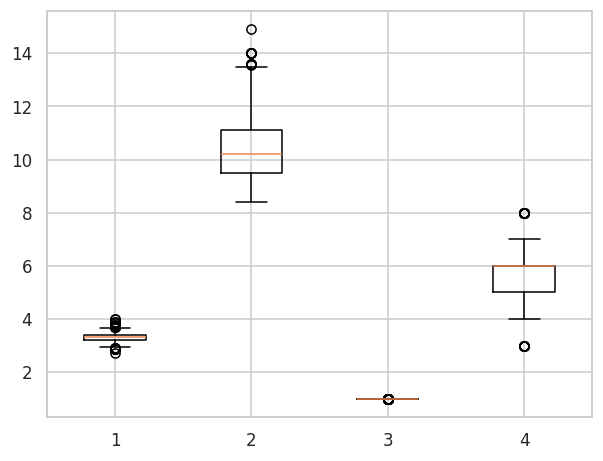

In [ ]:
plt.boxplot(red_dataset[num_cols].dropna())

In [ ]:
red_dataset[num_cols].dropna()

,pH,alcohol,density,quality
0,3.51,9.4,0.99780,5
1,3.20,9.8,0.99680,5
2,3.26,9.8,0.99700,5
3,3.16,9.8,0.99800,6
4,3.51,9.4,0.99780,5
...,...,...,...,...
1594,3.45,10.5,0.99490,5
1595,3.52,11.2,0.99512,6
1596,3.42,11.0,0.99574,6
1597,3.57,10.2,0.99547,5


array([[<Axes: title={'center': 'fixed acidity'}>,
        <Axes: title={'center': 'volatile acidity'}>,
        <Axes: title={'center': 'citric acid'}>],
       [<Axes: title={'center': 'residual sugar'}>,
        <Axes: title={'center': 'chlorides'}>,
        <Axes: title={'center': 'free sulfur dioxide'}>],
       [<Axes: title={'center': 'total sulfur dioxide'}>,
        <Axes: title={'center': 'density'}>,
        <Axes: title={'center': 'pH'}>],
       [<Axes: title={'center': 'sulphates'}>,
        <Axes: title={'center': 'alcohol'}>,
        <Axes: title={'center': 'quality'}>]], dtype=object)

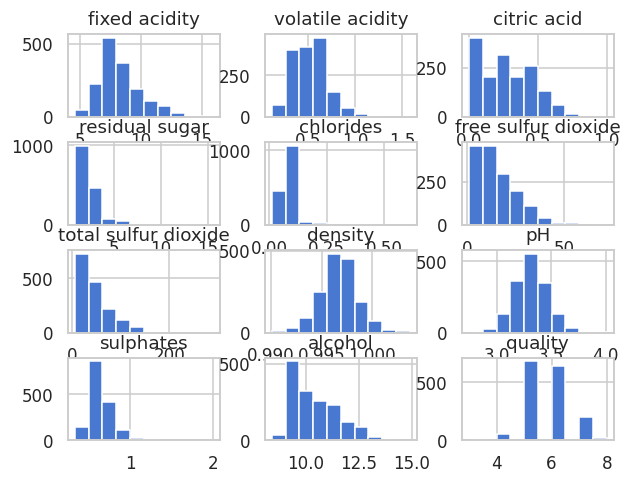

In [ ]:
red_dataset.dropna().hist()

In [ ]:
# Carregando o dataset
white_dataset = pd.read_csv('winequality-white.csv', sep=';')

white_dataset

In [ ]:
# Quantas amostras temos por classe?
print("Distribuição das classes:")
print(red_dataset['pH'].value_counts())
print(white_dataset['alcohol'].value_counts())

In [ ]:
df_model = df.copy()

df_model["good_quality"] = (df_model["quality"] >= 7).astype(int)

X = df_model.drop(columns=["quality", "good_quality"])
y = df_model["good_quality"]

X = pd.get_dummies(X, columns=["type"], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.25,
random_state=42,
stratify=y
)

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

baseline = DummyClassifier(strategy="most_frequent")

baseline.fit(X_train, y_train)

y_pred_baseline = baseline.predict(X_test)

print("Acurácia baseline:", accuracy_score(y_test, y_pred_baseline))
print(classification_report(y_test, y_pred_baseline))


Acurácia baseline: 0.8036923076923077
              precision    recall  f1-score   support

           0       0.80      1.00      0.89      1306
           1       0.00      0.00      0.00       319

    accuracy                           0.80      1625
   macro avg       0.40      0.50      0.45      1625
weighted avg       0.65      0.80      0.72      1625



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
baseline = DummyClassifier(strategy="prior")

baseline.fit(X_train, y_train)

y_pred_baseline = baseline.predict(X_test)

print("Acurácia baseline:", accuracy_score(y_test, y_pred_baseline))
print(classification_report(y_test, y_pred_baseline))

Acurácia baseline: 0.8036923076923077
              precision    recall  f1-score   support

           0       0.80      1.00      0.89      1306
           1       0.00      0.00      0.00       319

    accuracy                           0.80      1625
   macro avg       0.40      0.50      0.45      1625
weighted avg       0.65      0.80      0.72      1625



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
baseline = DummyClassifier(strategy="stratified")

baseline.fit(X_train, y_train)

y_pred_baseline = baseline.predict(X_test)

print("Acurácia baseline:", accuracy_score(y_test, y_pred_baseline))
print(classification_report(y_test, y_pred_baseline))

Acurácia baseline: 0.660923076923077
              precision    recall  f1-score   support

           0       0.79      0.78      0.79      1306
           1       0.15      0.16      0.16       319

    accuracy                           0.66      1625
   macro avg       0.47      0.47      0.47      1625
weighted avg       0.67      0.66      0.66      1625



In [ ]:
baseline = DummyClassifier(strategy="uniform")

baseline.fit(X_train, y_train)

y_pred_baseline = baseline.predict(X_test)

print("Acurácia baseline:", accuracy_score(y_test, y_pred_baseline))
print(classification_report(y_test, y_pred_baseline))

Acurácia baseline: 0.512
              precision    recall  f1-score   support

           0       0.81      0.51      0.63      1306
           1       0.21      0.53      0.30       319

    accuracy                           0.51      1625
   macro avg       0.51      0.52      0.46      1625
weighted avg       0.70      0.51      0.56      1625



In [ ]:
baseline = DummyClassifier(strategy="constant", constant=1)

baseline.fit(X_train, y_train)

y_pred_baseline = baseline.predict(X_test)

print("Acurácia baseline:", accuracy_score(y_test, y_pred_baseline))
print(classification_report(y_test, y_pred_baseline))

Acurácia baseline: 0.1963076923076923
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1306
           1       0.20      1.00      0.33       319

    accuracy                           0.20      1625
   macro avg       0.10      0.50      0.16      1625
weighted avg       0.04      0.20      0.06      1625



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
baseline = DummyClassifier(strategy="constant", constant=0)

baseline.fit(X_train, y_train)

y_pred_baseline = baseline.predict(X_test)

print("Acurácia baseline:", accuracy_score(y_test, y_pred_baseline))
print(classification_report(y_test, y_pred_baseline))

Acurácia baseline: 0.8036923076923077
              precision    recall  f1-score   support

           0       0.80      1.00      0.89      1306
           1       0.00      0.00      0.00       319

    accuracy                           0.80      1625
   macro avg       0.40      0.50      0.45      1625
weighted avg       0.65      0.80      0.72      1625



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import numpy as np from sklearn.base import BaseEstimator, RegressorMixin
    # Mixin classes should always be on the left-hand side for a correct MRO
class MyEstimator(RegressorMixin, BaseEstimator):
def __init__(self, *, param=1):
    self.param = param
def fit(self, X, y=None):
    self.is_fitted_ = True
    return self
def predict(self, X):
    return np.full(shape=X.shape[0], fill_value=self.param)
    estimator = MyEstimator(param=0)
    X = np.array([[1, 2], [2, 3], [3, 4]])
    y = np.array([-1, 0, 1])
    estimator.fit(X, y).predict(X)
    array([0, 0, 0])
    estimator.score(X, y)
    0.0